<a href="https://colab.research.google.com/github/ErbolTakhirov/Learning-notebooks/blob/main/ML/Linear_Regression/mse_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
#@title Create Data Function
def create_data()->tuple:
    X = np.random.normal(170, 9, 600).round(1)
    y = .9*X - 88 + np.random.randn(600)*5
    sns.scatterplot(x=X, y=y, color='black')
    plt.show()
    return X, y

# TASK

Вы работаете с реальным экспериментальным набором данных. Мы собрали информацию о **600 студентах** в возрасте **от 18 до 25 лет**. Для каждого участника был измерен **рост** (в сантиметрах) и **масса тела** (в килограммах). Это данные взрослых людей без выраженных нарушений телосложения.


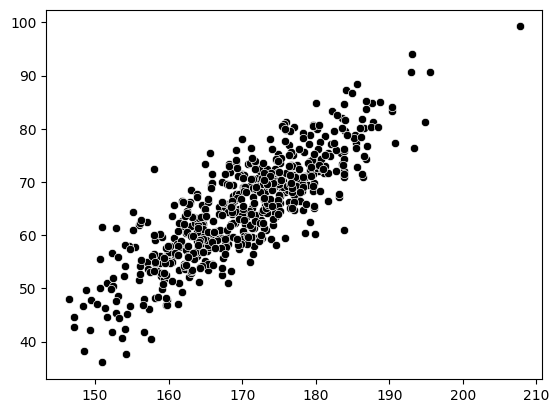

In [ ]:
X, y = create_data()

In [ ]:
X.shape, y.shape

((600,), (600,))

#  Цель

На основе имеющихся данных необходимо построить **линейную модель**, описывающую зависимость массы тела от роста. Иными словами, вы должны аппроксимировать зависимость вида:

$$
\hat{y} = \omega_0 + \omega_1 \cdot x
$$

где:

* $x$ — рост человека (в см),
* $\hat{y}$ — предсказанная масса тела,
* $\omega_0$, $\omega_1$ — коэффициенты, которые нужно определить.

---

##  Постановка задачи

Найдите такие значения параметров $\omega_0$, $\omega_1$, которые минимизируют функцию ошибки (лосс-функцию) — **среднеквадратичную ошибку** (MSE):

$$
L(\omega_0, \omega_1) = \frac{1}{n} \sum_{i=1}^n \left( \hat{y}_i - y_i \right)^2 = \frac{1}{n} \sum_{i=1}^n \left( \omega_0 + \omega_1 \cdot x_i - y_i \right)^2
$$

где:

* $x_i$ — рост $i$-го участника,
* $y_i$ — реальная масса $i$-го участника,
* $\hat{y}_i$ — предсказанная моделью масса,
* $n = 600$ — общее число наблюдений.

---

##  Что требуется

1. Реализуйте на Python код, который:

   * принимает на вход массивы `X` (рост) и `y` (масса),
   * численно находит $\omega_0$ и $\omega_1$, при которых MSE принимает наименьшее значение из возможных.
2. Постройте график:

   * точки реальных наблюдений,
   * предсказанную линейную зависимость.
3. Проверьте, насколько хорошо линейная модель описывает данные.

---

Для решения данной задачи не очень хорошо работает метод приближенного вычисления производных. Вам необходимо будет получить частные производные loss руками для подсчета значений градиента. В остальном, используйте метод градиентного спуска.


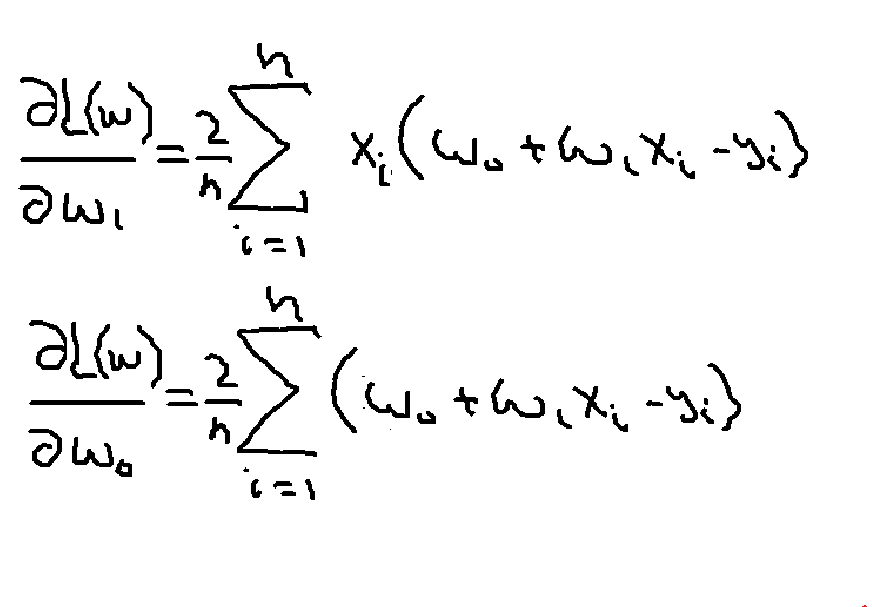

In [ ]:
def mse(X, y, w_0, w_1)-> float:
  y_pred = X*w_1 + w_0
  return ((y_pred - y)**2).mean().item()

def dl_dw_1(X, y, w_0, w_1)->float:
  y_pred = X*w_1 + w_0
  return (2*(X * (y_pred - y)).mean()).item()

def dl_dw_0(X, y, w_0, w_1)->float:
  y_pred = X*w_1 + w_0
  return (2*(y_pred - y)).mean().item()

In [ ]:
X_std = (X - X.mean()) / X.std()

In [ ]:
X_std

array([ 8.42954312e-02,  3.32170341e-01,  5.04605061e-01, -6.48552128e-01,
        6.23153930e-01, -1.59694309e+00,  1.65776225e+00,  7.84811480e-01,
       -1.51072573e+00,  7.20148460e-01, -5.08448918e-01,  6.33931100e-01,
       -1.90948102e+00, -2.29745914e+00, -1.98492121e+00,  2.56730151e-01,
        4.11867513e-02, -3.42534386e-02,  4.93827891e-01, -1.82326366e+00,
       -1.28440516e+00, -2.92905518e-01, -4.65340238e-01,  2.67507321e-01,
       -4.50306086e-02,  4.07610531e-01,  7.63257140e-01,  4.72273551e-01,
        3.96833361e-01,  1.19434394e+00,  7.63257140e-01, -8.53318357e-01,
       -1.42025138e-01,  2.99838831e-01,  1.27404111e-01,  9.68023370e-01,
       -1.75860064e+00, -9.28758547e-01, -9.71867227e-01,  4.07610531e-01,
       -8.85649867e-01, -1.44606271e+00, -7.77878168e-01, -1.11197044e+00,
       -1.92192865e-03, -4.43785898e-01,  1.10812658e+00, -1.70471479e+00,
        1.27404111e-01, -9.89164585e-02,  1.50688187e+00,  6.33931100e-01,
       -6.70106468e-01,  

In [ ]:
Learning_Rate = 0.01
N_ITER = 350
W_0, W_1 = np.random.randn(2)

In [ ]:
loss_steps = []
norm_grad = []
for _ in range(N_ITER):
  loss_ = mse(X_std, y, W_0, W_1)
  print(f'LOSS: {loss_}')
  loss_steps.append(loss_)
  gradient = np.array([dl_dw_0(X_std, y, W_0, W_1), dl_dw_1(X_std, y, W_0, W_1)])
  norm_grad.append(np.linalg.norm(gradient).item())
  W_0 = W_0 - Learning_Rate * gradient[0]
  W_1 = W_1 - Learning_Rate * gradient[1]

LOSS: 4275.375647868731
LOSS: 4107.12105792376
LOSS: 3945.529349740611
LOSS: 3790.3366732015143
LOSS: 3641.2896266533653
LOSS: 3498.1448431485233
LOSS: 3360.668593070473
LOSS: 3228.6364024955137
LOSS: 3101.8326866673224
LOSS: 2980.0503979859277
LOSS: 2863.0906879363165
LOSS: 2750.7625824046695
LOSS: 2642.882669852076
LOSS: 2539.2748018365646
LOSS: 2439.769805394468
LOSS: 2344.2052068114785
LOSS: 2252.4249663323753
LOSS: 2164.2792233762443
LOSS: 2079.624051841177
LOSS: 1998.3212250988972
LOSS: 1920.2379902956122
LOSS: 1845.2468515905373
LOSS: 1773.2253619781832
LOSS: 1704.0559233544782
LOSS: 1637.625594500272
LOSS: 1573.8259066686926
LOSS: 1512.5526864752437
LOSS: 1453.7058858014555
LOSS: 1397.189418434349
LOSS: 1342.91100317498
LOSS: 1290.7820131598821
LOSS: 1240.717331149382
LOSS: 1192.6352105464978
LOSS: 1146.4571419194876
LOSS: 1102.1077248101071
LOSS: 1059.5145446182582
LOSS: 1018.6080543620066
LOSS: 979.3214611199021
LOSS: 941.5906169701852
LOSS: 905.3539142487974
LOSS: 870.552184

Text(0.5, 1.0, 'LOSS')

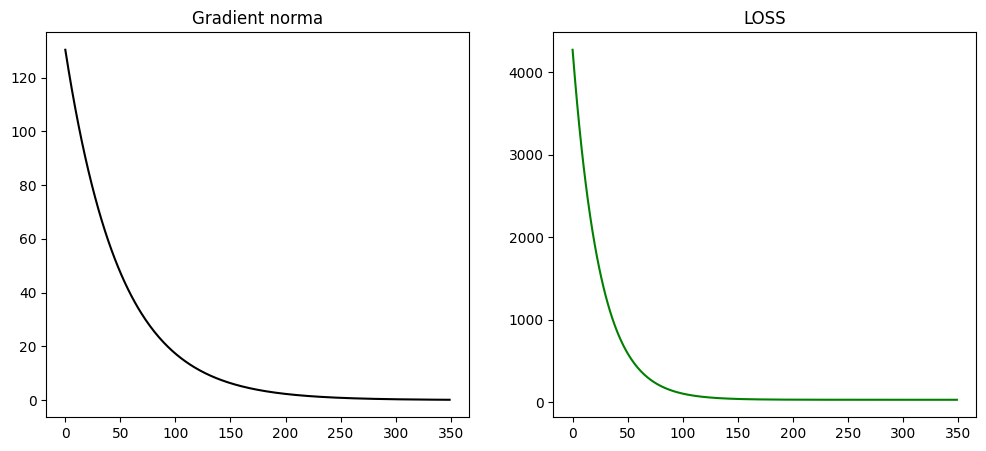

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))
sns.lineplot(norm_grad, color='black', ax = ax[0]).set_title('Gradient norma')
sns.lineplot(loss_steps, color='green', ax = ax[1]).set_title('LOSS')

<Axes: >

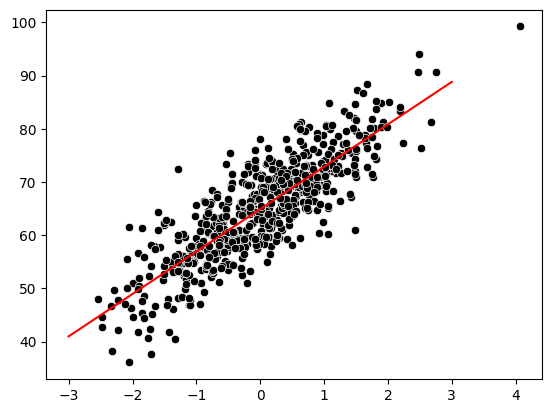

In [ ]:
xxx = np.linspace(-3, 3, 10)
yyy = W_0 + W_1*xxx
sns.scatterplot(x=X_std, y=y, color='black')
sns.lineplot(x=xxx, y=yyy, color='red')

## Predict

In [ ]:
def predcit(x:float)->float:
  mean_ = X.mean()
  sigma_ = X.std()
  xx = (x - mean_) / sigma_
  return (xx*W_1 + W_0).item()

In [ ]:
predcit(170)

64.87853643883226

## Without w_0

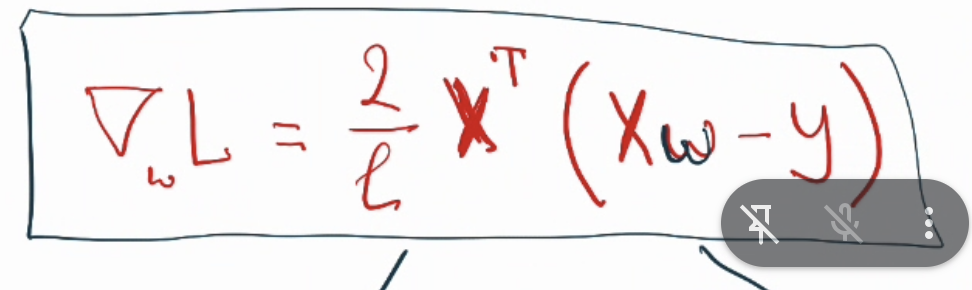

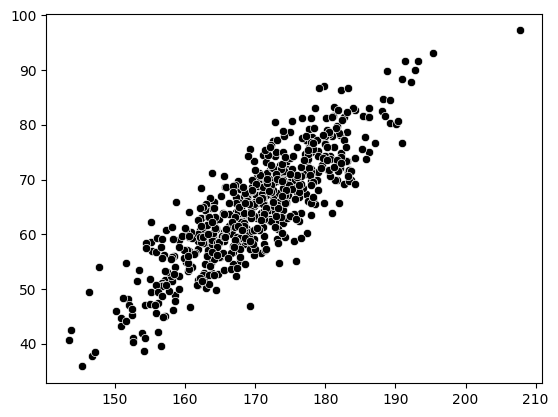

In [ ]:
X, y = create_data()
mean_ = X.mean()
sigma_ = X.std()
X = (X - mean_) / sigma_

In [ ]:
X = np.array([np.ones(X.shape), X]).T

In [ ]:
w = np.random.randn(X.shape[1])
N_ITER = 100
LEARNING_RATE = 1e-4

In [ ]:
X.shape, y.shape, w.shape

((600, 2), (600,), (2,))

In [ ]:
def predict(X:np.ndarray, w:np.ndarray)->np.ndarray:
  " doc "
  y_pred = X@w
  return y_pred

def mse(y_true:np.ndarray, y_pred:np.ndarray)-> float:
  # (y_pred - y_true) @ (y_pred - y_true)
  loss = np.linalg.norm(y_pred - y_true) / y_pred.shape[0]
  return loss.item()

def gradient(X:np.ndarray,
             y_true:np.ndarray,
             w:np.ndarray)->tuple[np.ndarray, float]:
  error = X@w - y_true
  grad = X.T @ error
  norm = np.linalg.norm(grad)
  return grad, norm.item()


In [ ]:
loss = []
grad_norm = []

for _ in range(N_ITER):
  y_pred = predict(X, w)
  loss_ = mse(y, y_pred)
  loss.append(loss_)
  grad, norm = gradient(X=X, y_true=y, w=w)
  grad_norm.append(norm)
  # correct of weights
  w = w - LEARNING_RATE * grad

y_pred = predict(X, w)
loss_ = mse(y, y_pred)
loss.append(loss_)

Text(0.5, 1.0, 'LOSS')

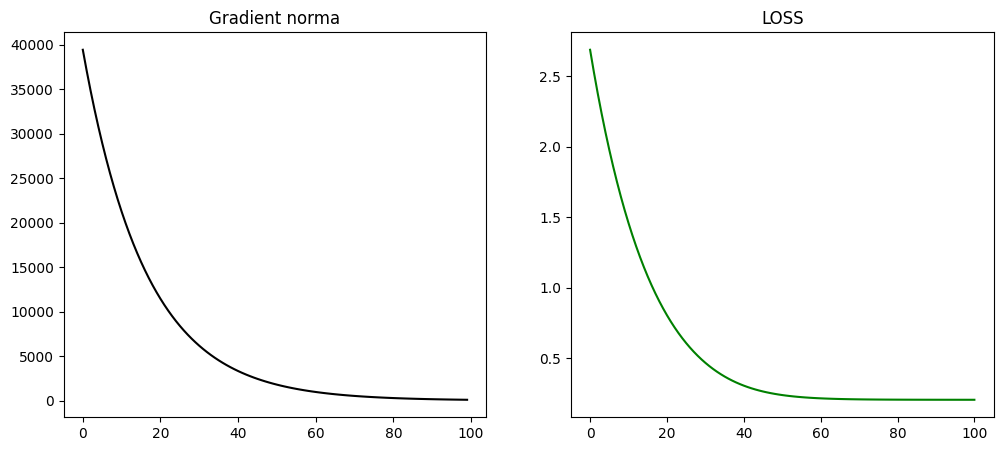

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))
sns.lineplot(grad_norm, color='black', ax = ax[0]).set_title('Gradient norma')
sns.lineplot(loss, color='green', ax = ax[1]).set_title('LOSS')

In [ ]:
X

array([[ 1.        , -0.11187601],
       [ 1.        , -1.27590386],
       [ 1.        ,  0.93020606],
       ...,
       [ 1.        , -0.07861807],
       [ 1.        , -0.84355066],
       [ 1.        , -1.10961416]])

In [ ]:
w

array([64.66091246,  8.50993227])

<Axes: >

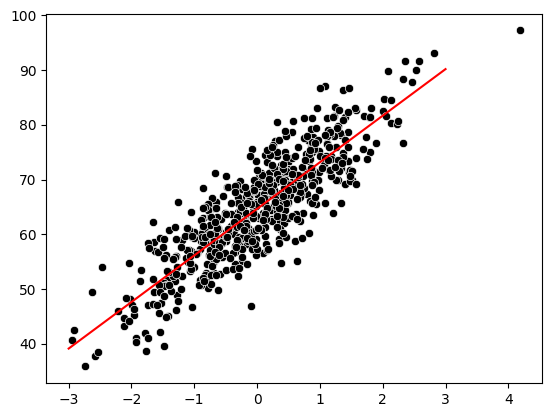

In [ ]:
xxx = np.linspace(-3, 3, 10)
yyy = w[0] + w[1]*xxx
sns.scatterplot(x=X[:, 1], y=y, color='black')
sns.lineplot(x=xxx, y=yyy, color='red')

In [ ]:
w

array([64.66091246,  8.50993227])

In [ ]:
def predcit_prod(x:float)->float:
  xx = (x - mean_) / sigma_
  return np.array([1, xx]) @ w

In [ ]:
predcit_prod(170)

np.float64(64.65226454015398)

# YOUR PART

In [ ]:
from sklearn.datasets import make_regression
import numpy as np

X, y = make_regression(
    n_samples=2000,
    n_features=2,
    noise=10,
    random_state=21
)
y = ((y - y.mean()) / y.std()) * 8000 + 50000

Text(0.5, 1.0, 'Feature 2 vs Target')

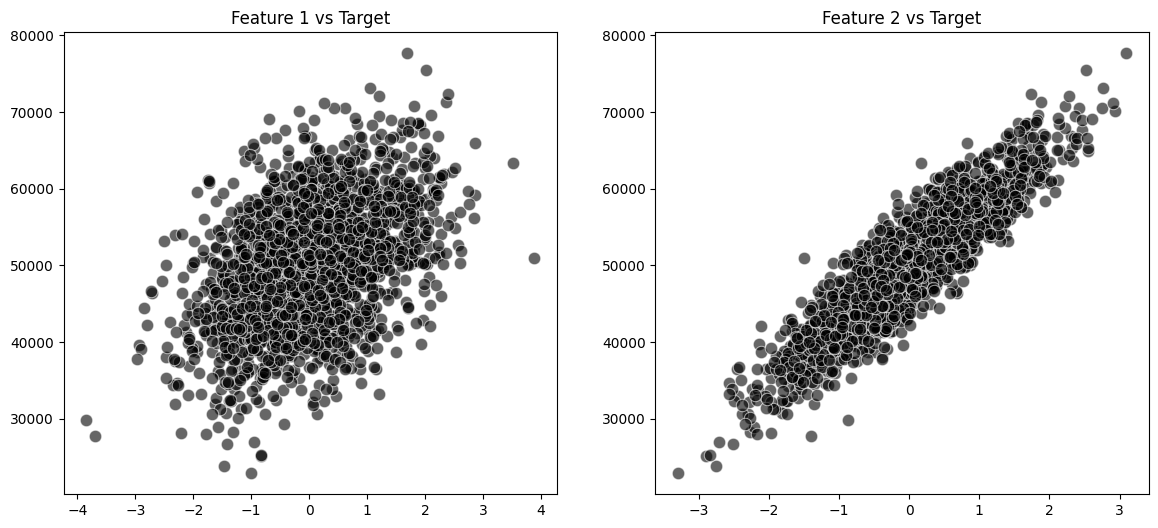

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=X[:, 0], y=y, ax=axes[0], alpha=0.6, s=80, color='black')
axes[0].set_title("Feature 1 vs Target")

sns.scatterplot(x=X[:, 1], y=y, ax=axes[1], alpha=0.6, s=80, color='black')
axes[1].set_title("Feature 2 vs Target")

In [ ]:
X.shape

(2000, 2)

In [ ]:
X

array([[ 0.33421416,  1.25783568],
       [ 0.79232602, -0.40790885],
       [ 1.56072214,  0.18328867],
       ...,
       [-0.28187825,  0.81631165],
       [ 1.25993225, -0.44438741],
       [ 1.12182456,  0.55617422]])

In [ ]:
X = np.array([np.ones(X.shape[0]), X[:, 0], X[:, 1]]).T
X

array([[ 1.        ,  0.33421416,  1.25783568],
       [ 1.        ,  0.79232602, -0.40790885],
       [ 1.        ,  1.56072214,  0.18328867],
       ...,
       [ 1.        , -0.28187825,  0.81631165],
       [ 1.        ,  1.25993225, -0.44438741],
       [ 1.        ,  1.12182456,  0.55617422]])

In [ ]:
X.shape

(2000, 3)

In [ ]:
w = np.random.randn(X.shape[1])

In [ ]:
w

array([-1.4634895 , -1.13246211,  1.36946911])

In [ ]:
def predict(X:np.ndarray, w:np.ndarray)->np.ndarray:
  " doc "
  y_pred = X@w
  return y_pred

def mse(y_true:np.ndarray, y_pred:np.ndarray)-> float:
  # (y_pred - y_true) @ (y_pred - y_true)
  loss = np.linalg.norm(y_pred - y_true) / y_pred.shape[0]
  return loss.item()

def gradient(X:np.ndarray,
             y_true:np.ndarray,
             w:np.ndarray)->tuple[np.ndarray, float]:
  error = X@w - y_true
  grad = X.T @ error
  norm = np.linalg.norm(grad)
  return grad, norm.item()

In [ ]:
w

array([-1.4634895 , -1.13246211,  1.36946911])

# TESTING


In [ ]:
N_ITER = 100
LR = 1e-4

In [ ]:

loss = []
grad_norm = []

for _ in range(N_ITER):
  y_pred = predict(X, w)
  loss_ = mse(y, y_pred)
  loss.append(loss_)
  grad, norm = gradient(X=X, y_true=y, w=w)
  grad_norm.append(norm)
  # correct of weights
  w = w - LR * grad

y_pred = predict(X, w)
loss_ = mse(y, y_pred)
loss.append(loss_)

In [ ]:
y_pred.shape

(2000,)

In [ ]:
grad_norm

[101361321.13246223,
 81003281.0126385,
 64754415.83953025,
 51781322.739503875,
 41420410.10480949,
 33143142.336214963,
 26528428.703002036,
 21240681.69978616,
 17012375.870895013,
 13630180.094657362,
 10923928.043384757,
 8757843.451492786,
 7023557.229655151,
 5634548.917864204,
 4521720.664712175,
 3629871.960588894,
 2914890.9887943873,
 2341516.26352662,
 1881552.234442217,
 1512446.3674071836,
 1216154.1382957466,
 978233.4140593144,
 787121.6455241698,
 633558.7959121416,
 510126.48260767263,
 410879.817555489,
 331053.21150385705,
 266825.2112048326,
 215130.46677161264,
 173509.33759102435,
 139987.565722168,
 112979.97586851424,
 91213.38049274724,
 73664.84080980657,
 59512.20962659816,
 48094.50036914663,
 38880.12003319705,
 31441.39758629123,
 25434.153737797267,
 20581.309062564087,
 16659.72802639238,
 13489.656724492352,
 10926.240243296708,
 8852.707977169464,
 7174.897145942045,
 5816.85029293032,
 4717.274987193784,
 3826.69593559698,
 3105.163327328123,
 2520.4

Text(0.5, 1.0, 'LOSS')

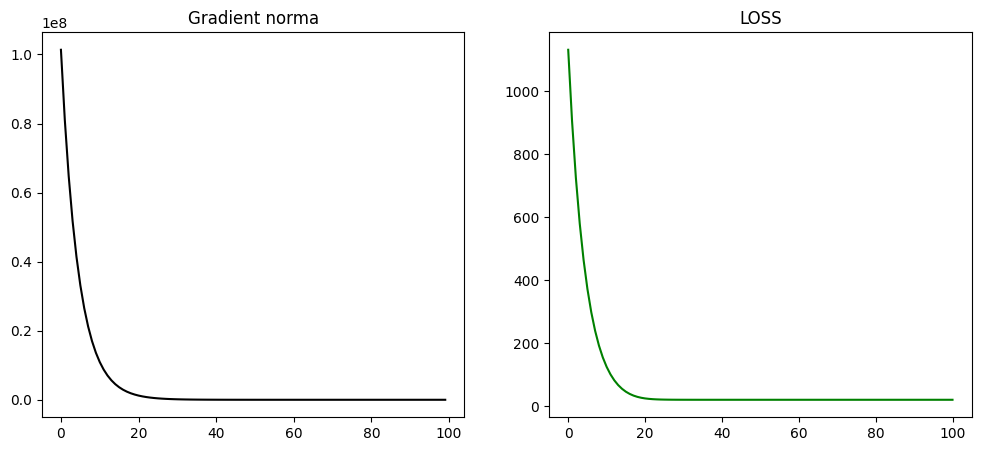

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))
sns.lineplot(grad_norm, color='black', ax = ax[0]).set_title('Gradient norma')
sns.lineplot(loss, color='green', ax = ax[1]).set_title('LOSS')

In [ ]:
w

array([49994.63468328,  3128.64117559,  7442.38529735])

<Axes: >

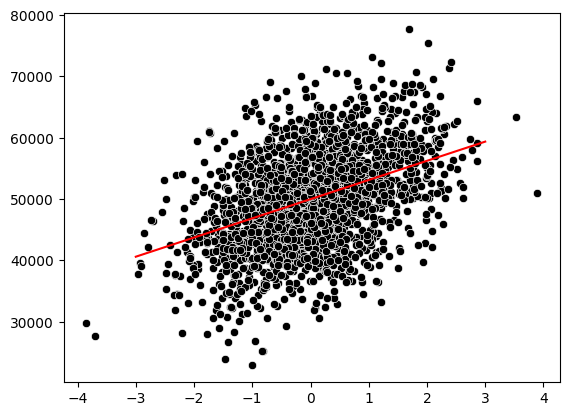

In [ ]:
x_line = np.linspace(3, -3, 10)
y_pred = w[0] + w[1] * x_line
sns.scatterplot(x=X[:, 1], y=y, color='black')
sns.lineplot(x=x_line, y=y_pred, color='red')

<Axes: >

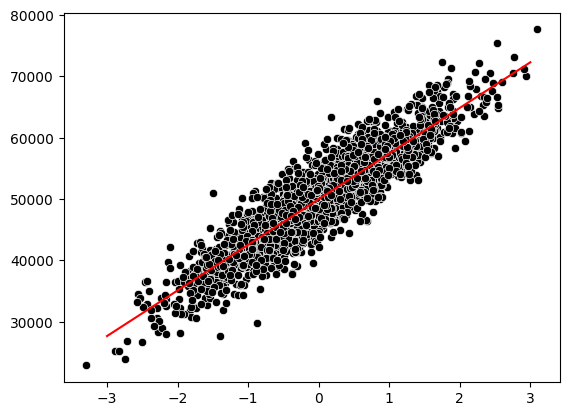

In [ ]:
x_line = np.linspace(3, -3, 10)
y_pred = w[0] + w[2] * x_line
sns.scatterplot(x=X[:, 2], y=y, color='black')
sns.lineplot(x=x_line, y=y_pred, color='red')

<Axes: >

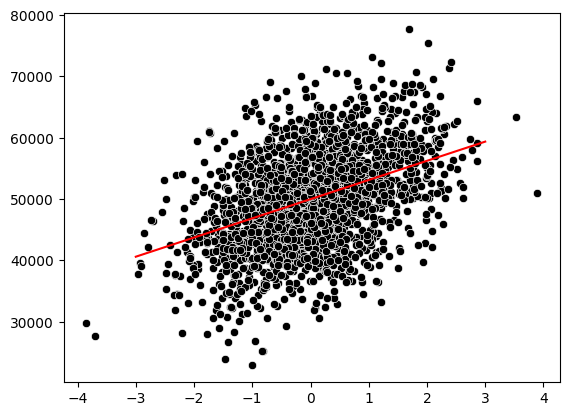

In [ ]:
xxx = np.linspace(-3, 3, 10)
yyy_2 = w[0] + w[1]*xxx
sns.scatterplot(x=X[:, 1], y=y, color='black')
sns.lineplot(x=xxx, y=yyy_2, color='red')

In [ ]:
X_test = X[:, 1:]
X_test

array([[ 0.33421416,  1.25783568],
       [ 0.79232602, -0.40790885],
       [ 1.56072214,  0.18328867],
       ...,
       [-0.28187825,  0.81631165],
       [ 1.25993225, -0.44438741],
       [ 1.12182456,  0.55617422]])

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
import numpy as np

# Создаем интерактивный 3D scatter
fig = go.Figure(data=[go.Scatter3d(
    x=X_test[:, 0],
    y=X_test[:, 1],
    z=y,
    mode='markers',
    marker=dict(
        size=5,
        color='black',

        opacity=0.8
    )
)])

fig.update_layout(
    title='3D Interactive Plot',
    scene=dict(
        xaxis_title='Feature 1',
        yaxis_title='Feature 2',
        zaxis_title='Target y'
    ),
    width=800,
    height=600
)

fig.add_trace(go.Scatter3d(
    x=x_line, y=x_line, z=y_pred,
    mode='lines', line=dict(color='red', width=4),
    name='XZ plane regression'
))


# fig.add_trace(go.Scatter3d(
#     x=x_line, y=x_line, z=yyy_2,
#     mode='lines', line=dict(color='red', width=4),
#     name='XZ plane regression'
# ))

fig.show()  # Можно крутить, масштабировать, сохранять углы!

In [ ]:
import numpy as np
import plotly.graph_objects as go

w0, w1, w2 = w
x1 = X_test[:, 0]
x2 = X_test[:, 1]

r1 = x1.max() - x1.min()
r2 = x2.max() - x2.min()
m1 = 0.1 * r1 if r1 > 0 else 1.0
m2 = 0.1 * r2 if r2 > 0 else 1.0
x1_lin = np.linspace(x1.min() - m1, x1.max() + m1, 30)
x2_lin = np.linspace(x2.min() - m2, x2.max() + m2, 30)
X1g, X2g = np.meshgrid(x1_lin, x2_lin)
Yg = w0 + w1 * X1g + w2 * X2g

fig = go.Figure([
    go.Surface(x=X1g, y=X2g, z=Yg, opacity=0.5, showscale=False, name="model"),
    go.Scatter3d(x=x1, y=x2, z=y, mode="markers", marker=dict(size=3), name="data"),  # ← z=y вместо фиктивного значения
])

fig.update_layout(
    title="Linear Model on 3D",
    scene=dict(xaxis_title="x1", yaxis_title="x2", zaxis_title="y")
)
fig.show()

In [ ]:
print(f'MAPE: {(np.abs(y - y_pred) / y).mean().item() * 100}%')

MAPE: 1.443448577188079%


In [ ]:
y, y_pred

(array([59538.36422354, 50393.0035214 , 56723.97253725, ...,
        54136.28954839, 50723.97106209, 57715.50438783]),
 array([72321.79057534, 67360.2003771 , 62398.61017887, 57437.01998063,
        52475.42978239, 47513.83958416, 42552.24938592, 37590.65918768,
        32629.06898945, 27667.47879121]))

In [ ]:
def eval_pred(x_1, x_2, w=w):
  xx = np.array([1, x_1, x_2])
  return (xx @ w).item()

In [ ]:
eval_pred(2, 5)

93463.84368621268